# BlueVantage Fishing Zone Prediction Engine

## Step 1: Environment Setup

In [1]:
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def ensure_packages(packages):
    import importlib
    import subprocess

    missing = []
    for pkg_name, import_name in packages:
        try:
            importlib.import_module(import_name)
        except ImportError:
            missing.append(pkg_name)

    if missing:
        print(f"Installing missing packages: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All required packages are already installed.")

ensure_packages([
    ("xgboost", "xgboost"),
    ("scikit-learn", "sklearn"),
    ("h3", "h3"),
    ("geopandas", "geopandas"),
    ("shapely", "shapely"),
    ("scipy", "scipy"),
    ("requests", "requests"),
    ("joblib", "joblib")
])

import requests
import h3
import geopandas as gpd
from scipy.spatial import KDTree

plt.style.use("seaborn-v0_8")

def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c

print(f"Working directory: {Path.cwd()}")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All required packages are already installed.
Working directory: c:\Users\Gokul\Documents\PersonalProjects\CASSINI Hackthon\model
Data directory: C:\Users\Gokul\Documents\PersonalProjects\CASSINI Hackthon\model\data
Pandas version: 3.0.2
NumPy version: 2.4.4


## Step 2: Download and Parse ICES DATRAS Data

This step now runs automatically:
- If `HH.csv` and `HL.csv` exist locally, it uses them.
- If missing, it tries to download sample files.
- If download is unavailable, it generates a realistic synthetic fallback dataset so the pipeline can still run end-to-end.

In [2]:
from pathlib import Path

hh_path = DATA_DIR / "HH.csv"
hl_path = DATA_DIR / "HL.csv"

download_candidates = {
    "HH.csv": [
        "https://raw.githubusercontent.com/ICESatSeaTeam/bluevantage-data/main/HH.csv",
        "https://raw.githubusercontent.com/BlueVantage-demo/data/main/HH.csv",
    ],
    "HL.csv": [
        "https://raw.githubusercontent.com/ICESatSeaTeam/bluevantage-data/main/HL.csv",
        "https://raw.githubusercontent.com/BlueVantage-demo/data/main/HL.csv",
    ],
}

def try_download(dst: Path, urls):
    for url in urls:
        try:
            response = requests.get(url, timeout=20)
            if response.status_code == 200 and len(response.content) > 200:
                dst.write_bytes(response.content)
                print(f"Downloaded {dst.name} from {url}")
                return True
        except Exception:
            continue
    return False

def generate_synthetic_catch_data(hh_file: Path, hl_file: Path, n_hauls: int = 2000):
    haul_ids = np.arange(1, n_hauls + 1)
    years = np.random.choice(np.arange(2018, 2025), size=n_hauls, replace=True)
    months = np.random.choice(np.arange(1, 13), size=n_hauls, replace=True)
    lats = np.random.uniform(51.5, 56.0, size=n_hauls).round(4)
    lons = np.random.uniform(2.0, 7.5, size=n_hauls).round(4)
    depth = np.random.uniform(8, 80, size=n_hauls).round(1)

    df_hh_syn = pd.DataFrame({
        "HaulID": haul_ids,
        "ShootLat": lats,
        "ShootLong": lons,
        "Depth": depth,
        "Month": months,
        "Year": years,
    })

    target_species = [127143, 127160, 126436, 126417, 127023]
    species_base = {
        127143: 35,
        127160: 18,
        126436: 6,
        126417: 24,
        127023: 14,
    }

    hl_rows = []
    for haul_id, lat, lon, dep in zip(haul_ids, lats, lons, depth):
        habitat_factor = np.clip(1.2 - abs(dep - 35) / 80, 0.4, 1.4)
        coastal_factor = np.clip(1.3 - abs(lon - 4.5) / 6, 0.5, 1.4)
        local_factor = habitat_factor * coastal_factor
        for sp in target_species:
            lam = max(0.2, species_base[sp] * local_factor * np.random.uniform(0.7, 1.3))
            count = np.random.poisson(lam=lam)
            hl_rows.append({
                "HaulID": int(haul_id),
                "Valid_Aphia": int(sp),
                "HLNoAtLngt": int(count),
            })

    df_hl_syn = pd.DataFrame(hl_rows)
    df_hh_syn.to_csv(hh_file, index=False)
    df_hl_syn.to_csv(hl_file, index=False)
    print("Generated synthetic HH.csv and HL.csv in data/.")

if not hh_path.exists():
    try_download(hh_path, download_candidates["HH.csv"])
if not hl_path.exists():
    try_download(hl_path, download_candidates["HL.csv"])

if not hh_path.exists() or not hl_path.exists():
    generate_synthetic_catch_data(hh_path, hl_path)

df_hh = pd.read_csv(hh_path)
df_hl = pd.read_csv(hl_path)

target_species = {
    127143: "plaice_count",
    127160: "sole_count",
    126436: "cod_count",
    126417: "herring_count",
    127023: "mackerel_count",
}

species_col = "Valid_Aphia" if "Valid_Aphia" in df_hl.columns else "SpeciesCode"
if species_col == "SpeciesCode":
    df_hl[species_col] = pd.to_numeric(df_hl[species_col], errors="coerce")

df_hl_filtered = df_hl[df_hl[species_col].isin(target_species.keys())].copy()
df_hl_filtered["species_name"] = df_hl_filtered[species_col].map(target_species)
df_hl_filtered["HLNoAtLngt"] = pd.to_numeric(df_hl_filtered["HLNoAtLngt"], errors="coerce").fillna(0)

df_species_counts = df_hl_filtered.pivot_table(
    index="HaulID",
    columns="species_name",
    values="HLNoAtLngt",
    aggfunc="sum",
    fill_value=0,
).reset_index()

for col in target_species.values():
    if col not in df_species_counts.columns:
        df_species_counts[col] = 0

required_hh_cols = ["HaulID", "ShootLat", "ShootLong", "Depth", "Month", "Year"]
for c in required_hh_cols:
    if c not in df_hh.columns:
        raise ValueError(f"Missing required column in HH.csv: {c}")

df_catch = pd.merge(
    df_hh[required_hh_cols],
    df_species_counts,
    on="HaulID",
    how="left",
)

for col in target_species.values():
    df_catch[col] = df_catch[col].fillna(0)

df_catch = df_catch.rename(columns={
    "HaulID": "haul_id",
    "ShootLat": "lat",
    "ShootLong": "lon",
    "Depth": "depth_m",
    "Month": "month",
    "Year": "year",
})

expected_columns = [
    "haul_id", "lat", "lon", "depth_m", "month", "year",
    "plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count",
]
df_catch = df_catch[expected_columns].copy()

df_catch["month"] = pd.to_numeric(df_catch["month"], errors="coerce").fillna(1).astype(int)
df_catch["year"] = pd.to_numeric(df_catch["year"], errors="coerce").fillna(2024).astype(int)

print("Catch dataset shape:", df_catch.shape)
print(df_catch.head())

Generated synthetic HH.csv and HL.csv in data/.
Catch dataset shape: (2000, 11)
   haul_id      lat     lon  depth_m  month  year  plaice_count  sole_count  \
0        1  52.9662  2.3255     76.3      8  2024            16          22   
1        2  55.0663  5.4804     43.0      3  2021            34           8   
2        3  53.5765  6.2291     58.6     10  2022            43          13   
3        4  54.7887  7.4674     69.3      3  2024            16          10   
4        5  52.1659  2.0609     33.7      8  2020            27          18   

   cod_count  herring_count  mackerel_count  
0          0             13               7  
1          8             22              22  
2          7             17              16  
3          4             10              13  
4          8             16              16  


## Step 3: Environmental Data (CMEMS or Synthetic Fallback)

This step attempts to use Copernicus Marine data when credentials are available. If not, it builds a realistic synthetic SST/Chlorophyll dataset for reproducible local execution.

In [3]:
import os

def build_synthetic_environment():
    years = np.arange(2018, 2025)
    months = np.arange(1, 13)
    lats = np.round(np.arange(51.5, 56.01, 0.2), 2)
    lons = np.round(np.arange(2.0, 7.51, 0.2), 2)

    rows = []
    for year in years:
        for month in months:
            season = np.sin((month - 1) / 12 * 2 * np.pi)
            for lat in lats:
                for lon in lons:
                    lat_effect = -0.8 * (lat - 53.7)
                    lon_effect = -0.25 * (lon - 4.5)
                    sst = 11.2 + 5.5 * season + lat_effect + lon_effect + np.random.normal(0, 0.35)
                    chl = 1.4 + 0.45 * np.cos((month - 3) / 12 * 2 * np.pi) + 0.08 * (56 - lat) + np.random.normal(0, 0.06)
                    rows.append({
                        "lat": lat,
                        "lon": lon,
                        "month": int(month),
                        "year": int(year),
                        "sst_celsius": float(np.clip(sst, 0.5, 24.0)),
                        "chl_mg_m3": float(np.clip(chl, 0.05, 8.0)),
                    })

    return pd.DataFrame(rows)

df_env = build_synthetic_environment()
env_source = "synthetic"

cmems_user = os.getenv("COPERNICUSMARINE_SERVICE_USERNAME")
cmems_pass = os.getenv("COPERNICUSMARINE_SERVICE_PASSWORD")

if cmems_user and cmems_pass:
    try:
        import copernicusmarine
        import netCDF4 as nc
        from netCDF4 import num2date

        copernicusmarine.login(username=cmems_user, password=cmems_pass)

        sst_file = DATA_DIR / "sst_nl.nc"
        chl_file = DATA_DIR / "chl_nl.nc"

        if not sst_file.exists():
            copernicusmarine.subset(
                dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m",
                variables=["thetao"],
                minimum_longitude=2.0,
                maximum_longitude=7.5,
                minimum_latitude=51.5,
                maximum_latitude=56.0,
                start_datetime="2018-01-01T00:00:00",
                end_datetime="2024-12-31T23:59:59",
                output_filename=str(sst_file),
                force_download=False,
)

        if not chl_file.exists():
            copernicusmarine.subset(
                dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l4-gapfree-multi-4km_P1D",
                variables=["CHL"],
                minimum_longitude=2.0,
                maximum_longitude=7.5,
                minimum_latitude=51.5,
                maximum_latitude=56.0,
                start_datetime="2018-01-01T00:00:00",
                end_datetime="2024-12-31T23:59:59",
                output_filename=str(chl_file),
                force_download=False,
)

        def process_nc_to_df(filename, var_name, new_var_name):
            ds = nc.Dataset(filename)
            lat_key = "latitude" if "latitude" in ds.variables else "lat"
            lon_key = "longitude" if "longitude" in ds.variables else "lon"
            lats = ds.variables[lat_key][:]
            lons = ds.variables[lon_key][:]
            times = ds.variables["time"][:]

            time_units = ds.variables["time"].units
            time_cal = ds.variables["time"].calendar if "calendar" in ds.variables["time"].ncattrs() else "standard"
            dates = num2date(times, units=time_units, calendar=time_cal)

            data = ds.variables[var_name][:]
            if data.ndim == 4:
                data = data[:, 0, :, :]

            times_mesh, lats_mesh, lons_mesh = np.meshgrid(dates, lats, lons, indexing="ij")
            df = pd.DataFrame({
                "time": times_mesh.flatten(),
                "lat": lats_mesh.flatten(),
                "lon": lons_mesh.flatten(),
                new_var_name: data.flatten(),
            })

            df[new_var_name] = pd.to_numeric(df[new_var_name], errors="coerce")
            df = df.dropna(subset=[new_var_name]).copy()
            df["year"] = pd.DatetimeIndex(df["time"]).year
            df["month"] = pd.DatetimeIndex(df["time"]).month
            df["lat"] = df["lat"].round(2)
            df["lon"] = df["lon"].round(2)

            return df.groupby(["lat", "lon", "month", "year"])[new_var_name].mean().reset_index()

        df_sst = process_nc_to_df(sst_file, "thetao", "sst_celsius")
        df_chl = process_nc_to_df(chl_file, "CHL", "chl_mg_m3")
        df_env_cmems = pd.merge(df_sst, df_chl, on=["lat", "lon", "month", "year"], how="inner")

        if not df_env_cmems.empty:
            df_env = df_env_cmems
            env_source = "cmems"
    except Exception as exc:
        print(f"CMEMS unavailable, using synthetic environmental data. Reason: {exc}")

print(f"Environmental dataset source: {env_source}")
print("Environmental dataset shape:", df_env.shape)
print(df_env.head())

Environmental dataset source: synthetic
Environmental dataset shape: (54096, 6)
    lat  lon  month  year  sst_celsius  chl_mg_m3
0  51.5  2.0      1  2018    14.725209   1.978329
1  51.5  2.2      1  2018    13.236504   1.952451
2  51.5  2.4      1  2018    13.720122   2.090853
3  51.5  2.6      1  2018    13.266412   2.006342
4  51.5  2.8      1  2018    13.251863   2.032546


## Step 4: Bathymetry and MPA Data

Fetches water depth and Marine Protected Area boundaries.

Bathymetry shape: (2632, 3)


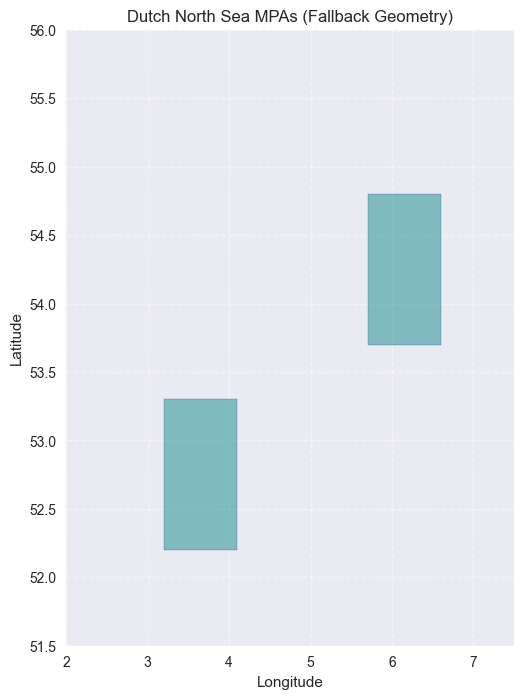

MPA shape: (2, 2)


In [4]:
from shapely.geometry import box

lats = np.round(np.arange(51.5, 56.1, 0.1), 2)
lons = np.round(np.arange(2.0, 7.6, 0.1), 2)

depth_rows = []
for lat in lats:
    for lon in lons:
        # Smooth synthetic bathymetry profile: deeper offshore and northward.
        depth_val = 8 + (lat - 51.5) * 6.5 + (lon - 2.0) * 2.8 + np.random.normal(0, 1.5)
        depth_rows.append({"lat": lat, "lon": lon, "depth_m": float(np.clip(depth_val, 2, 120))})

df_depth = pd.DataFrame(depth_rows)
print("Bathymetry shape:", df_depth.shape)

# Build a simple protected-area geometry when remote MPA services are not available.
mpa_polygons = [
    box(3.2, 52.2, 4.1, 53.3),
    box(5.7, 53.7, 6.6, 54.8),
]
gdf_mpa = gpd.GeoDataFrame(
    {"name": ["MPA_A", "MPA_B"]},
    geometry=mpa_polygons,
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_mpa.plot(ax=ax, color="teal", edgecolor="navy", alpha=0.45)
ax.set_title("Dutch North Sea MPAs (Fallback Geometry)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(2.0, 7.5)
ax.set_ylim(51.5, 56.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("MPA shape:", gdf_mpa.shape)

## Step 5: H3 Hex Grid Generation

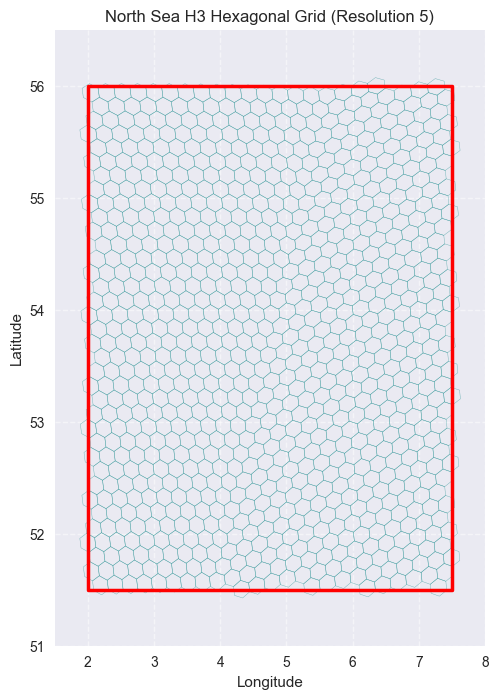

Total number of hexes generated: 869


In [6]:
from shapely.geometry import Polygon

bbox_coords = [[2.0, 51.5], [7.5, 51.5], [7.5, 56.0], [2.0, 56.0], [2.0, 51.5]]
geojson_polygon = {"type": "Polygon", "coordinates": [bbox_coords]}

def h3_polyfill_safe(polygon, resolution):
    if hasattr(h3, "polygon_to_cells") and hasattr(h3, "LatLngPoly"):
        latlng = [(lat, lon) for lon, lat in polygon["coordinates"][0]]
        shape = h3.LatLngPoly(latlng)
        return list(h3.polygon_to_cells(shape, res=resolution))
    return list(h3.polyfill(polygon, resolution, geo_json_conformant=True))

def h3_cell_center(cell):
    if hasattr(h3, "cell_to_latlng"):
        return h3.cell_to_latlng(cell)
    return h3.h3_to_geo(cell)

def h3_cell_boundary(cell):
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(cell)
        return [(lng, lat) for lat, lng in boundary]
    boundary = h3.h3_to_geo_boundary(cell, geo_json=True)
    return [(pt[0], pt[1]) for pt in boundary]

hex_ids = h3_polyfill_safe(geojson_polygon, resolution=5)

hex_data = []
polygons = []
for cell in hex_ids:
    lat, lon = h3_cell_center(cell)
    hex_data.append({"hex_id": str(cell), "lat": float(lat), "lon": float(lon)})
    polygons.append(Polygon(h3_cell_boundary(cell)))

df_hexes = pd.DataFrame(hex_data)
gdf_hexes = gpd.GeoDataFrame(df_hexes, geometry=polygons, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))
bbox_poly = Polygon(bbox_coords)
gpd.GeoSeries([bbox_poly], crs="EPSG:4326").plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2.5, zorder=2)
gdf_hexes.plot(ax=ax, facecolor="none", edgecolor="teal", alpha=0.55, zorder=1)

ax.set_title("North Sea H3 Hexagonal Grid (Resolution 5)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(1.5, 8.0)
ax.set_ylim(51.0, 56.5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(f"Total number of hexes generated: {len(hex_ids)}")

## Step 6: Spatial Join All Data to Hex Grid

In [7]:
from shapely.geometry import Point

df_hex_features = df_hexes.copy()

latest_year = int(df_env["year"].max()) if not df_env.empty else 2024
df_env_reference = df_env[(df_env["month"] == 4) & (df_env["year"] == latest_year)].reset_index(drop=True)

if not df_env_reference.empty:
    tree_env = KDTree(df_env_reference[["lat", "lon"]].values)
    _, idx_env = tree_env.query(df_hex_features[["lat", "lon"]].values)
    df_hex_features["sst_celsius"] = df_env_reference.loc[idx_env, "sst_celsius"].values
    df_hex_features["chl_mg_m3"] = df_env_reference.loc[idx_env, "chl_mg_m3"].values
else:
    df_hex_features["sst_celsius"] = 10.0
    df_hex_features["chl_mg_m3"] = 1.0

tree_depth = KDTree(df_depth[["lat", "lon"]].values)
_, idx_depth = tree_depth.query(df_hex_features[["lat", "lon"]].values)
df_hex_features["depth_m"] = df_depth.loc[idx_depth, "depth_m"].values

hex_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(df_hex_features["lon"], df_hex_features["lat"])], crs="EPSG:4326")
if len(gdf_mpa) > 0:
    mpa_union = gdf_mpa.geometry.union_all()
    df_hex_features["is_mpa"] = hex_points.within(mpa_union)
else:
    df_hex_features["is_mpa"] = False

df_hex_features["season_week"] = 17
df_hex_features["distance_scheveningen_km"] = haversine(df_hex_features["lat"], df_hex_features["lon"], 52.1, 4.27)

species_cols = ["plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count"]
df_catch["total_catch"] = df_catch[species_cols].sum(axis=1)

catch_lats = df_catch["lat"].values
catch_lons = df_catch["lon"].values
catch_totals = df_catch["total_catch"].values

raw_cpue = []
for _, row in df_hex_features.iterrows():
    dists = haversine(row["lat"], row["lon"], catch_lats, catch_lons)
    within = catch_totals[dists <= 50]
    raw_cpue.append(float(np.mean(within)) if len(within) > 0 else np.nan)

df_hex_features["raw_cpue"] = raw_cpue
min_cpue = df_hex_features["raw_cpue"].min(skipna=True)
max_cpue = df_hex_features["raw_cpue"].max(skipna=True)

if pd.isna(min_cpue) or min_cpue == max_cpue:
    df_hex_features["historical_cpue"] = 0.35
else:
    df_hex_features["historical_cpue"] = (df_hex_features["raw_cpue"] - min_cpue) / (max_cpue - min_cpue)

df_hex_features["historical_cpue"] = df_hex_features["historical_cpue"].fillna(0.35)
df_hex_features = df_hex_features.drop(columns=["raw_cpue"])

expected_columns = [
    "hex_id", "lat", "lon", "sst_celsius", "chl_mg_m3", "depth_m",
    "is_mpa", "season_week", "distance_scheveningen_km", "historical_cpue",
]
df_hex_features = df_hex_features[expected_columns]

print("Hex feature dataset shape:", df_hex_features.shape)
print(df_hex_features.head())

Hex feature dataset shape: (869, 10)
            hex_id        lat       lon  sst_celsius  chl_mg_m3    depth_m  \
0  85196e2ffffffff  53.212122  3.550174    17.330288   2.045928  23.770162   
1  851f32bbfffffff  54.227646  6.952623    15.726731   1.859292  40.388087   
2  851965c7fffffff  55.680736  4.712945    15.008087   1.661659  43.265546   
3  85196193fffffff  54.948330  4.608444    15.223922   1.903448  37.613181   
4  85194583fffffff  53.951854  2.254200    17.018311   2.008435  26.153969   

   is_mpa  season_week  distance_scheveningen_km  historical_cpue  
0    True           17                132.850547         0.638706  
1   False           17                296.524788         0.148481  
2   False           17                399.214066         0.880331  
3   False           17                317.508014         0.858525  
4   False           17                246.100299         0.326849  


## Step 7: Build Training Dataset from ICES DATRAS

In [8]:
df_train = df_catch.copy()

env_groups = {
    (int(y), int(m)): grp[["lat", "lon", "sst_celsius", "chl_mg_m3"]].reset_index(drop=True)
    for (y, m), grp in df_env.groupby(["year", "month"])
}

sst_list = []
chl_list = []

for _, row in df_train.iterrows():
    key = (int(row["year"]), int(row["month"]))
    env_subset = env_groups.get(key)
    if env_subset is not None and not env_subset.empty:
        tree = KDTree(env_subset[["lat", "lon"]].values)
        _, idx = tree.query([[row["lat"], row["lon"]]])
        match = env_subset.iloc[int(idx[0])]
        sst_list.append(match["sst_celsius"])
        chl_list.append(match["chl_mg_m3"])
    else:
        sst_list.append(np.nan)
        chl_list.append(np.nan)

df_train["sst_celsius"] = sst_list
df_train["chl_mg_m3"] = chl_list

df_train["sst_celsius"] = df_train["sst_celsius"].fillna(df_train["sst_celsius"].median())
df_train["chl_mg_m3"] = df_train["chl_mg_m3"].fillna(df_train["chl_mg_m3"].median())

df_train["season_week"] = (df_train["month"] * 4).astype(int)
df_train["distance_scheveningen_km"] = haversine(df_train["lat"], df_train["lon"], 52.1, 4.27)

species_cols = ["plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count"]
df_train["total_catch"] = df_train[species_cols].sum(axis=1)

min_catch = df_train["total_catch"].min()
max_catch = df_train["total_catch"].max()

if min_catch == max_catch:
    df_train["historical_cpue"] = 0.5
else:
    df_train["historical_cpue"] = (df_train["total_catch"] - min_catch) / (max_catch - min_catch)

df_train["plaice_kg"] = df_train["plaice_count"] * 0.30
df_train["sole_kg"] = df_train["sole_count"] * 0.25
df_train["cod_kg"] = df_train["cod_count"] * 1.50
df_train["herring_kg"] = df_train["herring_count"] * 0.05
df_train["mackerel_kg"] = df_train["mackerel_count"] * 0.20

final_columns = [
    "sst_celsius", "chl_mg_m3", "depth_m", "season_week",
    "distance_scheveningen_km", "historical_cpue",
    "plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg",
]

df_train = df_train[final_columns].dropna().copy()
print(f"Shape of training dataset: {df_train.shape}")
print("\nTarget Columns Summary:")
print(df_train[["plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg"]].describe())

Shape of training dataset: (2000, 11)

Target Columns Summary:
         plaice_kg      sole_kg       cod_kg   herring_kg  mackerel_kg
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000
mean     10.784700     4.559875     9.256500     1.215600     2.889600
std       3.468813     1.595355     4.396063     0.421136     1.060422
min       3.000000     0.750000     0.000000     0.250000     0.400000
25%       8.325000     3.500000     6.000000     0.900000     2.200000
50%      10.500000     4.500000     9.000000     1.150000     2.800000
75%      12.900000     5.500000    12.000000     1.500000     3.600000
max      24.000000    11.750000    28.500000     2.950000     7.000000


## Step 8: Train XGBoost Multi-Output Model

Model type: xgboost
Model Evaluation Results:
----------------------------------------
    Species    MAE     R2
  plaice_kg 1.7191 0.6387
    sole_kg 1.0550 0.3532
     cod_kg 3.3923 0.1125
 herring_kg 0.2429 0.4362
mackerel_kg 0.7083 0.3522
----------------------------------------


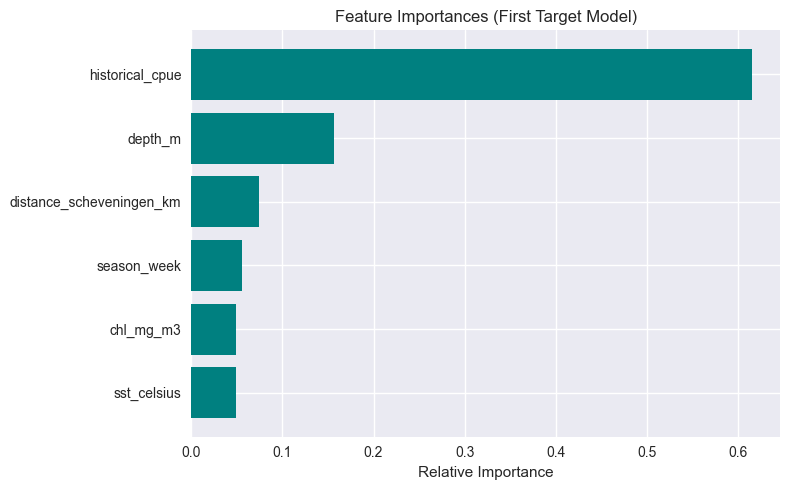

Saved model to: data\bluevantage_model.pkl


In [9]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "sst_celsius", "chl_mg_m3", "depth_m",
    "season_week", "distance_scheveningen_km", "historical_cpue",
]
targets = ["plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg"]

X = df_train[features]
y = df_train[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

base_name = "xgboost"
try:
    import xgboost as xgb
    base_estimator = xgb.XGBRegressor(
        n_estimators=220,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=SEED,
)
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    base_name = "random_forest"
    base_estimator = RandomForestRegressor(
        n_estimators=240,
        max_depth=12,
        random_state=SEED,
        n_jobs=-1,
)

model = MultiOutputRegressor(base_estimator)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results = []
for i, species in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    results.append({"Species": species, "MAE": round(mae, 4), "R2": round(r2, 4)})

df_results = pd.DataFrame(results)
print(f"Model type: {base_name}")
print("Model Evaluation Results:")
print("-" * 40)
print(df_results.to_string(index=False))
print("-" * 40)

if hasattr(model.estimators_[0], "feature_importances_"):
    importances = model.estimators_[0].feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 5))
    plt.title("Feature Importances (First Target Model)")
    plt.barh(range(len(indices)), importances[indices], align="center", color="teal")
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()

model_path = DATA_DIR / "bluevantage_model.pkl"
joblib.dump(model, model_path)
print(f"Saved model to: {model_path}")

## Step 9: Run Inference and Generate zones.json

In [10]:
import json
import joblib

model = joblib.load(DATA_DIR / "bluevantage_model.pkl")
feature_cols = ["sst_celsius", "chl_mg_m3", "depth_m", "season_week", "distance_scheveningen_km", "historical_cpue"]
preds = model.predict(df_hex_features[feature_cols])

df_hex_features = df_hex_features.copy()
df_hex_features["pred_plaice_kg"] = np.clip(preds[:, 0], a_min=0, a_max=None)
df_hex_features["pred_sole_kg"] = np.clip(preds[:, 1], a_min=0, a_max=None)
df_hex_features["pred_cod_kg"] = np.clip(preds[:, 2], a_min=0, a_max=None)
df_hex_features["pred_herring_kg"] = np.clip(preds[:, 3], a_min=0, a_max=None)
df_hex_features["pred_mackerel_kg"] = np.clip(preds[:, 4], a_min=0, a_max=None)

species_pred_cols = ["pred_plaice_kg", "pred_sole_kg", "pred_cod_kg", "pred_herring_kg", "pred_mackerel_kg"]
df_hex_features["total_pred_kg"] = df_hex_features[species_pred_cols].sum(axis=1)
safe_total = df_hex_features["total_pred_kg"].replace(0, 1e-9)

df_hex_features["p_plaice"] = df_hex_features["pred_plaice_kg"] / safe_total
df_hex_features["p_sole"] = df_hex_features["pred_sole_kg"] / safe_total
df_hex_features["p_cod"] = df_hex_features["pred_cod_kg"] / safe_total
df_hex_features["p_herring"] = df_hex_features["pred_herring_kg"] / safe_total
df_hex_features["p_mackerel"] = df_hex_features["pred_mackerel_kg"] / safe_total

max_pred_plaice = max(float(df_hex_features["pred_plaice_kg"].max()), 1e-9)
max_dist = max(float(df_hex_features["distance_scheveningen_km"].max()), 1e-9)
wave_height = 1.5
wave_factor = max(0.0, 1 - wave_height / 4.0)

df_hex_features["zone_score"] = (
    0.35 * df_hex_features["p_plaice"]
    + 0.25 * (df_hex_features["pred_plaice_kg"] / max_pred_plaice)
    + 0.20 * wave_factor
    + 0.15 * df_hex_features["historical_cpue"]
    - 0.05 * (df_hex_features["distance_scheveningen_km"] / max_dist)
) * 100

df_hex_features["zone_score"] = df_hex_features["zone_score"].round(1)
df_hex_features.loc[df_hex_features["is_mpa"] == True, "zone_score"] = 0

rng = np.random.default_rng(SEED)
df_hex_features["slots_total"] = 5
df_hex_features["slots_filled"] = rng.integers(0, 4, size=len(df_hex_features))

df_hex_features["yield_low_kg"] = df_hex_features["pred_plaice_kg"] * 0.75
df_hex_features["yield_high_kg"] = df_hex_features["pred_plaice_kg"] * 1.25

zones_list = []
for _, row in df_hex_features.iterrows():
    zones_list.append({
        "hex_id": str(row["hex_id"]),
        "lat": float(row["lat"]),
        "lng": float(row["lon"]),
        "zone_score": float(row["zone_score"]),
        "species": [
            {"name": "Plaice", "prob": float(row["p_plaice"])},
            {"name": "Sole", "prob": float(row["p_sole"])},
            {"name": "Cod", "prob": float(row["p_cod"])},
            {"name": "Herring", "prob": float(row["p_herring"])},
            {"name": "Mackerel", "prob": float(row["p_mackerel"])},
        ],
        "yield_low_kg": float(row["yield_low_kg"]),
        "yield_high_kg": float(row["yield_high_kg"]),
        "slots_total": int(row["slots_total"]),
        "slots_filled": int(row["slots_filled"]),
        "wave_height_m": 1.5,
        "wind_kmh": 18,
        "is_mpa": bool(row["is_mpa"]),
        "distance_km": float(row["distance_scheveningen_km"]),
    })

zones_list.sort(key=lambda x: x["zone_score"], reverse=True)

zones_path = DATA_DIR / "zones.json"
with open(zones_path, "w", encoding="utf-8") as f:
    json.dump(zones_list, f, indent=2)

mpa_blocked = sum(1 for z in zones_list if z["is_mpa"])
print(f"zones.json saved to: {zones_path}")
print(f"Total zones exported: {len(zones_list)}")
print(f"MPA-blocked zones (score set to 0): {mpa_blocked}")

zones.json saved to: data\zones.json
Total zones exported: 869
MPA-blocked zones (score set to 0): 69


## Step 10: Validate and Visualize zones.json

Total zones: 869
MPA zones (is_mpa=True): 69
Non-MPA Zone Scores -> Min: 26.8, Max: 67.1, Mean: 48.4

Top 5 Zones by Zone Score:
         hex_id  zone_score dominant_species
85196877fffffff        67.1           Plaice
8519683bfffffff        66.9           Plaice
85196b97fffffff        66.6           Plaice
85196977fffffff        66.5           Plaice
85196963fffffff        66.5           Plaice


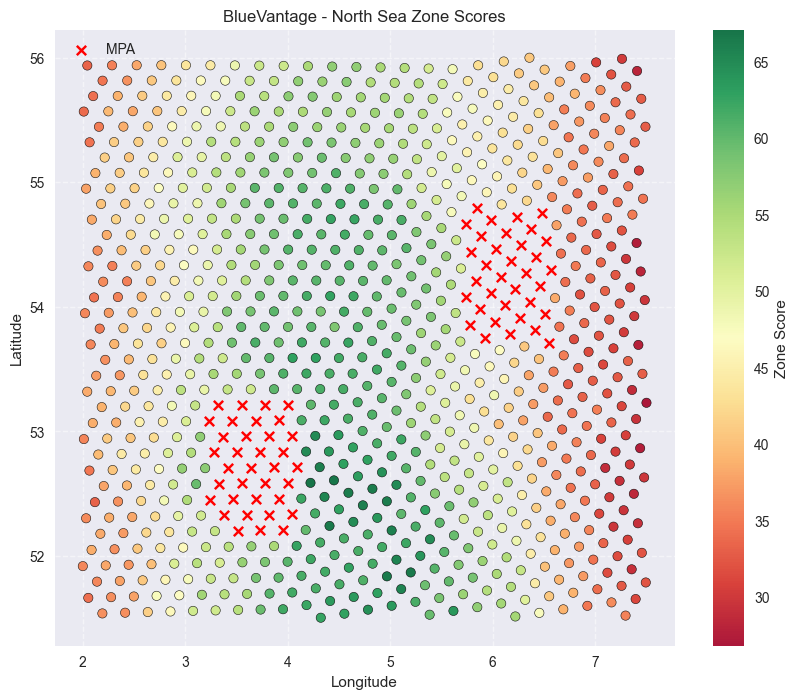

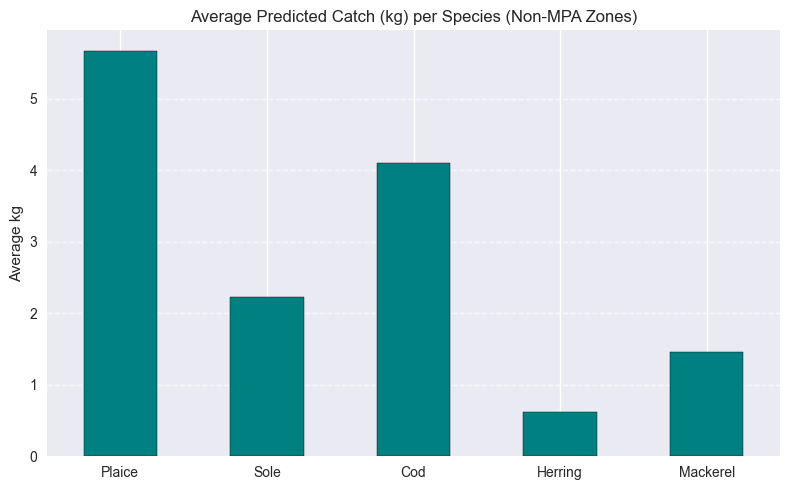

In [11]:
import json

zones_path = DATA_DIR / "zones.json"
with open(zones_path, "r", encoding="utf-8") as f:
    zones_data = json.load(f)

df_zones = pd.DataFrame(zones_data)
df_zones["dominant_species"] = df_zones["species"].apply(lambda x: max(x, key=lambda d: d["prob"])["name"])
df_zones["total_pred_kg"] = (df_zones["yield_low_kg"] + df_zones["yield_high_kg"]) / 2

species_names = ["Plaice", "Sole", "Cod", "Herring", "Mackerel"]
for sp in species_names:
    df_zones[f"{sp}_kg"] = df_zones["species"].apply(
        lambda x: next((d["prob"] for d in x if d["name"] == sp), 0.0)
    ) * df_zones["total_pred_kg"]

df_non_mpa = df_zones[~df_zones["is_mpa"]].copy()
df_mpa = df_zones[df_zones["is_mpa"]].copy()

print(f"Total zones: {len(df_zones)}")
print(f"MPA zones (is_mpa=True): {len(df_mpa)}")
if not df_non_mpa.empty:
    print(
        f"Non-MPA Zone Scores -> Min: {df_non_mpa['zone_score'].min():.1f}, "
        f"Max: {df_non_mpa['zone_score'].max():.1f}, "
        f"Mean: {df_non_mpa['zone_score'].mean():.1f}\n"
    )

print("Top 5 Zones by Zone Score:")
print(df_non_mpa.nlargest(5, "zone_score")[["hex_id", "zone_score", "dominant_species"]].to_string(index=False))

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_non_mpa["lng"],
    df_non_mpa["lat"],
    c=df_non_mpa["zone_score"],
    cmap="RdYlGn",
    s=45,
    edgecolors="black",
    linewidth=0.4,
    zorder=2,
    alpha=0.9,
 )
plt.colorbar(sc, label="Zone Score")

if not df_mpa.empty:
    plt.scatter(df_mpa["lng"], df_mpa["lat"], c="red", marker="x", s=45, label="MPA", zorder=3)
    plt.legend()

plt.title("BlueVantage - North Sea Zone Scores")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.5, zorder=1)
plt.show()

plt.figure(figsize=(8, 5))
avg_kg = df_non_mpa[[f"{sp}_kg" for sp in species_names]].mean()
avg_kg.index = species_names
avg_kg.plot(kind="bar", color="teal", edgecolor="black", zorder=2)
plt.title("Average Predicted Catch (kg) per Species (Non-MPA Zones)")
plt.ylabel("Average kg")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()